# COMP3710 Lab 1 - Sierpinski Triangle

This notebook implements a GPU-accelerated Sierpinski Triangle using PyTorch.

## Project goals

- Generate the Sierpinski Triangle using vectorised PyTorch operations.
- Process pixel coordinates in parallel on the GPU.
- Compare different recursion depths.
- Create different colour visualisations.
- Estimate the box-counting dimension.
- Compare the estimated dimension with the theoretical dimension.
- Compare CPU and GPU execution times.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
Device: cuda
GPU name: Tesla T4


## 1. Basic Sierpinski Triangle Generation

The Sierpinski Triangle can be constructed by repeatedly creating three half-sized copies of the current point set, positioned towards the three vertices of a triangle.

At every recursion level, PyTorch uses broadcasting to generate the three new point groups in parallel.

In [2]:
def generate_sierpinski_triangle(depth, computation_device):
    """
    Generate points belonging to a Sierpinski Triangle.
    生成谢尔宾斯基三角形中的所有点。

    Parameters
    ----------
    depth : int
        Number of recursion levels.
        递归深度。

    computation_device : torch.device
        Device used for tensor calculations.
        Tensor计算使用的设备，例如CPU或GPU。

    Returns
    -------
    torch.Tensor
        Point coordinates with shape [number_of_points, 2].
        形状为[点的数量, 2]的坐标Tensor。
    """

    # 等边三角形的高度 / Height of an equilateral triangle
    triangle_height = (3.0 ** 0.5) / 2.0

    # 三角形的三个顶点：左下、右下、顶部
    # Three vertices: bottom-left, bottom-right and top
    vertices = torch.tensor(
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.5, triangle_height]
        ],
        dtype=torch.float32,
        device=computation_device
    )

    # 从三角形中心的一个点开始
    # Start with one point at the centre of the triangle
    points = torch.tensor(
        [[0.5, triangle_height / 3.0]],
        dtype=torch.float32,
        device=computation_device
    )

    # 每次递归都会让每个旧点产生三个新点
    # Each recursion makes every existing point produce three new points
    for _ in range(depth):

        # points[:, None, :] 的形状是 [N, 1, 2]
        # vertices[None, :, :] 的形状是 [1, 3, 2]
        #
        # PyTorch广播会一次并行计算N个点到三个顶点的中点
        # Broadcasting calculates the three new point groups in parallel
        points = (points[:, None, :] + vertices[None, :, :]) / 2.0

        # 把形状从[N, 3, 2]重新整理为[3N, 2]
        # Reshape the result from [N, 3, 2] to [3N, 2]
        points = points.reshape(-1, 2)

    return points

Recursion depth: 10
Number of points: 59049
Expected number of points: 59049
Tensor device: cuda:0


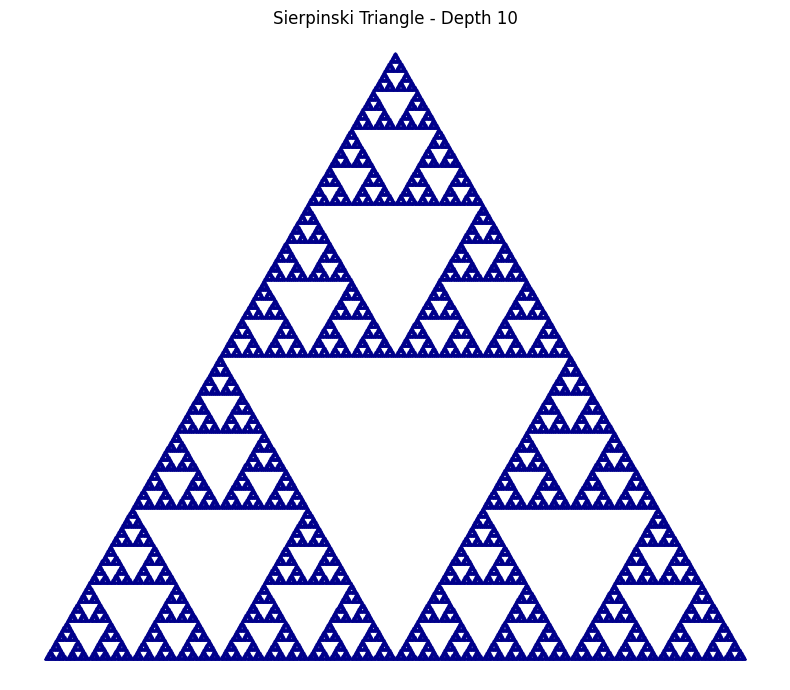

In [3]:
# 设置递归深度 / Set the recursion depth
depth = 10

# 使用前面选择的device生成分形
# Generate the fractal using the selected device
sierpinski_points = generate_sierpinski_triangle(depth, device)

# 输出运行信息，方便Demo时证明结果正确
# Display information for verification during the demo
print("Recursion depth:", depth)
print("Number of points:", sierpinski_points.shape[0])
print("Expected number of points:", 3 ** depth)
print("Tensor device:", sierpinski_points.device)

# Matplotlib不能直接绘制CUDA Tensor
# 所以只在绘图前把结果移回CPU并转换成NumPy数组
# Matplotlib cannot directly plot a CUDA tensor,
# so the result is moved to the CPU only for plotting
points_for_plotting = sierpinski_points.detach().cpu().numpy()

# 创建图像 / Create the plot
plt.figure(figsize=(8, 7))

plt.scatter(
    points_for_plotting[:, 0],
    points_for_plotting[:, 1],
    s=0.5,
    color="darkblue"
)

plt.title(f"Sierpinski Triangle - Depth {depth}")

# 保持横轴和纵轴比例相同，避免三角形变形
# Keep equal axis scaling to avoid distorting the triangle
plt.axis("equal")

# 隐藏坐标轴，使分形图更清晰
# Hide the axes for a clearer visualisation
plt.axis("off")

plt.tight_layout()
plt.show()